# Banking Financial Health Classification: Exploratory Data Analysis

**Project:** ARB Apex Bank - Rural Banking Risk Assessment System  
---

## Objective
Perform comprehensive exploratory data analysis on the synthetic banking dataset to:
1. Understand data distributions and characteristics
2. Identify patterns in financial health status
3. Detect correlations and multicollinearity
4. Analyze temporal trends across 12 quarters
5. Compare regional differences in bank performance
6. Inform feature engineering and modeling decisions

## Analysis Structure
1. Data Loading & Initial Assessment
2. Univariate Analysis
3. Target Variable Analysis
4. Bivariate Analysis (Risk vs Features)
5. Correlation Analysis & Multicollinearity
6. Temporal Analysis (Quarterly Trends)
7. Regional Comparison
8. Missing Value Analysis
9. Key Findings Summary

# Setup and Data Loading 


In [77]:
# import libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats 
import warnings

# configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

#plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Libraries loaded successfully...')

Libraries loaded successfully...


In [78]:
# Load dataset 
data_path = 'data/raw/banking_data_raw.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully...")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows")
df.head()

Dataset loaded successfully...
Shape: (2688, 35)

First few rows


,bank_id,bank_name,region,bank_size,lending_style,quarter_num,year,quarter,date,total_assets,total_equity,liquid_assets,total_loans,non_performing_loans,loan_loss_provisions,current_deposits,liquidity_ratio,capital_adequacy_ratio,cash_reserve_ratio,leverage_ratio,loan_to_deposit_ratio,npl_ratio,net_income,return_on_assets,return_on_equity,net_interest_margin,operating_expenses,cost_to_income_ratio,staff_count,branches,concentration_risk,deposit_volatility,financial_health_status,consecutive_losses,risk_reasons
0,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,1,2021,Q1,2021-Q1,47.72,7.98,8.70,17.48,1.09,0.96,36.87,18.24,16.73,22.31,19.31,47.43,6.24,2.46,5.16,30.85,11.55,1.80,70.52,57.0,6.0,30.82,17.38,0,0,NaN
1,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,2,2021,Q2,2021-Q2,49.23,8.37,8.75,15.48,1.00,1.18,35.03,17.77,17.00,21.43,11.90,44.18,6.48,2.20,4.47,26.32,7.21,1.69,92.28,80.0,10.0,49.16,26.72,0,0,NaN
2,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,3,2021,Q3,2021-Q3,44.00,7.48,7.43,26.73,1.86,0.99,35.37,16.88,17.00,18.00,18.55,75.57,6.95,2.74,6.22,36.58,7.56,2.36,50.34,29.0,11.0,23.67,8.46,0,0,NaN
3,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,4,2021,Q4,2021-Q4,47.60,8.06,8.10,15.73,1.15,1.10,36.57,17.02,16.94,14.20,16.18,43.02,7.31,1.80,3.78,22.31,6.81,3.53,64.47,55.0,7.0,40.76,29.12,0,0,NaN
4,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,5,2022,Q1,2022-Q1,51.87,8.83,9.01,27.19,2.02,1.66,39.63,17.36,17.02,24.84,16.07,68.61,7.43,0.53,1.03,6.05,3.85,2.55,90.62,25.0,2.0,17.37,7.66,0,0,NaN


# Data Assessment 


In [79]:
#Basic info
print("Dataset Information:")
print("-"*70)
df.info()


Dataset Information:
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2688 entries, 0 to 2687
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bank_id                  2688 non-null   object 
 1   bank_name                2688 non-null   object 
 2   region                   2688 non-null   object 
 3   bank_size                2688 non-null   object 
 4   lending_style            2688 non-null   object 
 5   quarter_num              2688 non-null   int64  
 6   year                     2688 non-null   int64  
 7   quarter                  2688 non-null   object 
 8   date                     2688 non-null   object 
 9   total_assets             2688 non-null   float64
 10  total_equity             2688 non-null   float64
 11  liquid_assets            2688 non-null   float64
 12  total_loans              2688 non-null  

In [80]:
# Descriptive statistics 
print("\nDescriptive Statistics:")
print("-" * 70)
df.describe().T



Descriptive Statistics:
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
quarter_num,2688.0,6.50,3.45,1.00,3.75,6.50,9.25,12.00
year,2688.0,2022.00,0.82,2021.00,2021.00,2022.00,2023.00,2023.00
total_assets,2688.0,140.95,193.27,4.80,26.65,66.16,162.69,1322.15
total_equity,2688.0,25.17,35.63,0.44,4.40,12.42,30.66,297.50
liquid_assets,2688.0,36.40,54.63,0.60,6.17,15.51,41.75,521.61
total_loans,2688.0,73.29,105.30,1.46,13.55,35.05,84.95,925.25
non_performing_loans,2688.0,6.37,10.03,0.04,0.88,2.57,7.15,94.63
loan_loss_provisions,2688.0,5.41,8.98,0.03,0.72,2.09,6.06,79.66
current_deposits,2688.0,109.18,150.36,3.41,20.94,51.22,126.32,1096.32
liquidity_ratio,2688.0,25.65,8.91,4.29,19.96,25.55,31.67,48.96


In [81]:
# check unique values in categorical columns 
categorical_cols = ['bank_id', 'region', 'bank_size', 'lending_style', 'quarter', 'date']

print("\nCategorical Variables - Unique Values")
print("-" * 70)
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}")
        print(f" Unique count: {df[col].nunique()}")
        if df[col].nunique() <= 15:
            print(f" Values: {df[col].unique()}")


Categorical Variables - Unique Values
----------------------------------------------------------------------

bank_id
 Unique count: 224

region
 Unique count: 10
 Values: ['Upper West' 'Greater Accra' 'Volta' 'Central' 'Eastern' 'Western'
 'Ashanti' 'Northern' 'Upper East' 'Bono']

bank_size
 Unique count: 3
 Values: ['Small' 'Large' 'Medium']

lending_style
 Unique count: 3
 Values: ['Moderate' 'Conservative' 'Aggressive']

quarter
 Unique count: 4
 Values: ['Q1' 'Q2' 'Q3' 'Q4']

date
 Unique count: 12
 Values: ['2021-Q1' '2021-Q2' '2021-Q3' '2021-Q4' '2022-Q1' '2022-Q2' '2022-Q3'
 '2022-Q4' '2023-Q1' '2023-Q2' '2023-Q3' '2023-Q4']


In [82]:
print("\nDataset Validation:")
print("-"*70)
print(f"Number of banks: {df['bank_id'].nunique()}")
print(f"Number of quarters: {df['quarter_num'].nunique()}")
print(f"Total records: {len(df)}")
print(f"Number of features: {df.shape[1]}")
print(f"Regions: {df['region'].nunique()}")

# Validate duplicates 
duplicates = df.duplicated(subset=['bank_id', 'quarter_num']).sum()
print(f"Duplicate records: {duplicates}")


Dataset Validation:
----------------------------------------------------------------------
Number of banks: 224
Number of quarters: 12
Total records: 2688
Number of features: 35
Regions: 10
Duplicate records: 0


# Target Variable Analysis 

In [83]:
target_counts = df['financial_health_status'].value_counts()
target_pct = df['financial_health_status'].value_counts(normalize=True)*100

print("Target Variable Distribution:..")
print("-"*70)
print(f"\nHEALTHY (0): {target_counts[0]:,} records ({target_pct[0]:.1f}%)")
print(f"\nHIGH_RISK (1): {target_counts[1]:,} records ({target_pct[1]:.1f}%)")
print(f"\nClass Imbalance Ratio: 1:{target_counts[0]/target_pct[1]:.2f}")

Target Variable Distribution:..
----------------------------------------------------------------------

HEALTHY (0): 1,767 records (65.7%)

HIGH_RISK (1): 921 records (34.3%)

Class Imbalance Ratio: 1:51.57


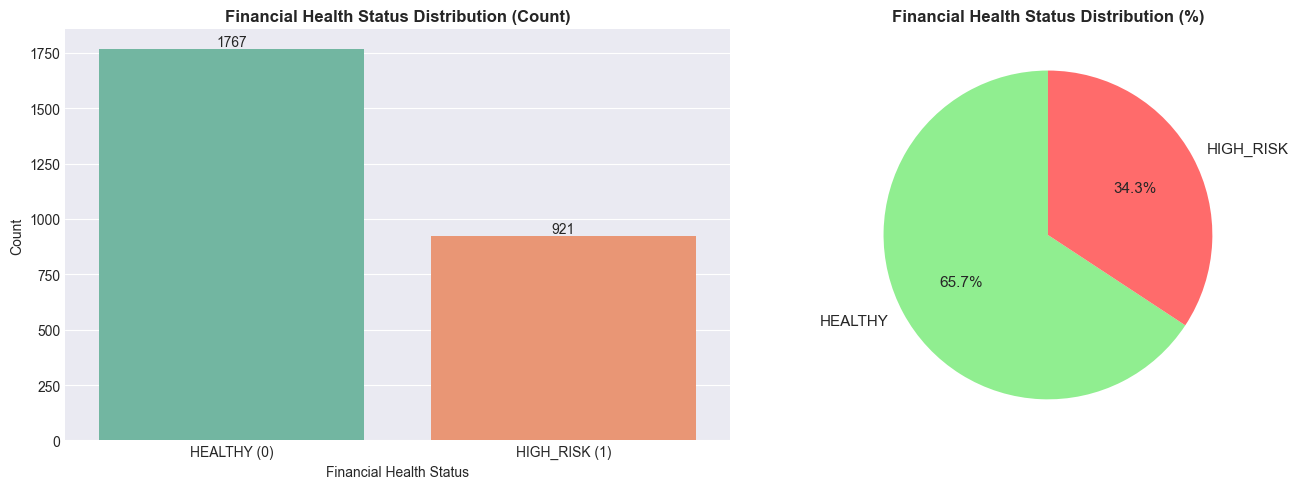

In [84]:
# Visualize target distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot 
sns.countplot(data=df, x='financial_health_status', ax=axes[0], palette='Set2')
axes[0].set_title('Financial Health Status Distribution (Count)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Financial Health Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['HEALTHY (0)', 'HIGH_RISK (1)'])

# Add count labels 
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart 
colors = ['#90EE90', '#FF6B6B']
axes[1].pie(target_counts, labels=['HEALTHY', 'HIGH_RISK'], autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Financial Health Status Distribution (%)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [85]:
# Analyze risk distribution by bank size 
print("\nRisk Distribution by Bnak size:")
print("-"*70)
risk_by_size = pd.crosstab(df['bank_size'], df['financial_health_status'],
                          normalize='index'
                          
                          )* 100
risk_by_size.columns = ['HEALTHY (%)', 'HIGH_RISK (%)']
print(risk_by_size.round(1))


Risk Distribution by Bnak size:
----------------------------------------------------------------------
           HEALTHY (%)  HIGH_RISK (%)
bank_size                            
Large             57.8           42.2
Medium            72.1           27.9
Small             62.3           37.7


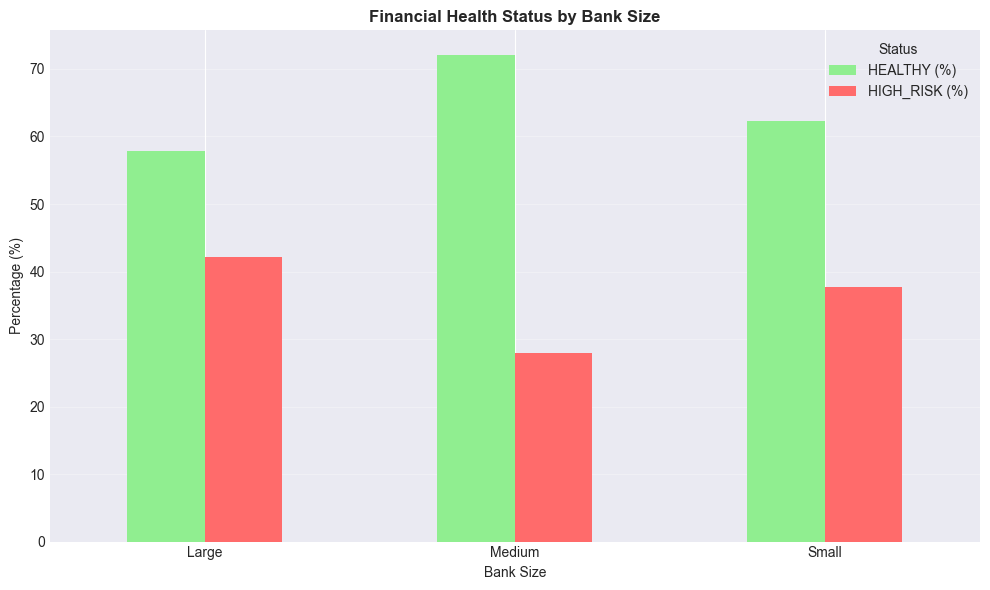

In [86]:
# visualize 
fig, ax = plt.subplots(figsize=(10, 6))
risk_by_size.plot(kind='bar', ax=ax, color=['#90EE90', '#FF6B6B'])
ax.set_title('Financial Health Status by Bank Size', fontweight='bold', fontsize=12)
ax.set_xlabel('Bank Size')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Status', loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
# Analyze risk distribution by region
print("\nRisk Distribution by Region:")
print("-" * 70)
risk_by_region = pd.crosstab(df['region'], df['financial_health_status'], 
                              normalize='index') * 100
risk_by_region.columns = ['HEALTHY (%)', 'HIGH_RISK (%)']
risk_by_region = risk_by_region.sort_values('HIGH_RISK (%)', ascending=False)
print(risk_by_region.round(1))




Risk Distribution by Region:
----------------------------------------------------------------------
               HEALTHY (%)  HIGH_RISK (%)
region                                   
Upper West            54.5           45.5
Greater Accra         55.8           44.2
Bono                  56.2           43.8
Volta                 58.3           41.7
Central               63.3           36.7
Northern              64.7           35.3
Ashanti               69.0           31.0
Western               71.8           28.2
Upper East            74.0           26.0
Eastern               77.5           22.5


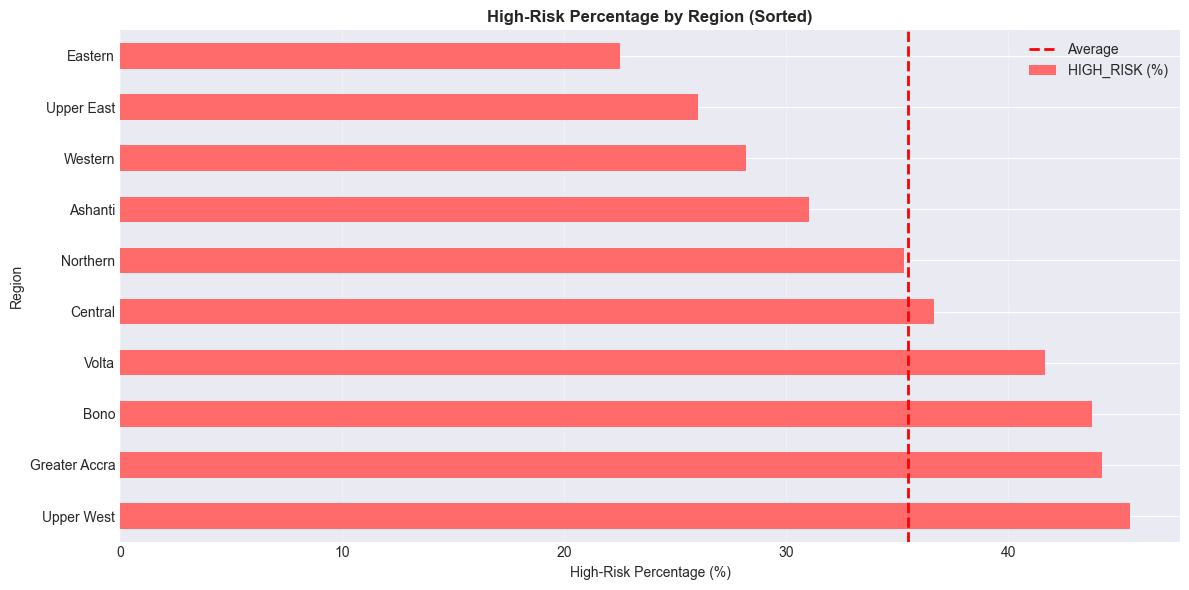

In [88]:
# Visualize top/bottom regions
fig, ax = plt.subplots(figsize=(12, 6))
risk_by_region['HIGH_RISK (%)'].plot(kind='barh', ax=ax, color='#FF6B6B')
ax.set_title('High-Risk Percentage by Region (Sorted)', fontweight='bold', fontsize=12)
ax.set_xlabel('High-Risk Percentage (%)')
ax.set_ylabel('Region')
ax.axvline(x=risk_by_region['HIGH_RISK (%)'].mean(), color='red', 
           linestyle='--', linewidth=2, label='Average')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Univariate Analysis 

In [89]:
#identify numerical columns 
exclude_cols = ['bank_id', 'bank_name', 'region', 'bank_size', 'lending_style', 
                'quarter', 'date', 'financial_health_status', 'risk_reasons', 
                'established_year', 'quarter_num', 'year']

numerical_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Numerical Features for Analysis: {len(numerical_cols)}")
print(numerical_cols)

Numerical Features for Analysis: 24
['total_assets', 'total_equity', 'liquid_assets', 'total_loans', 'non_performing_loans', 'loan_loss_provisions', 'current_deposits', 'liquidity_ratio', 'capital_adequacy_ratio', 'cash_reserve_ratio', 'leverage_ratio', 'loan_to_deposit_ratio', 'npl_ratio', 'net_income', 'return_on_assets', 'return_on_equity', 'net_interest_margin', 'operating_expenses', 'cost_to_income_ratio', 'staff_count', 'branches', 'concentration_risk', 'deposit_volatility', 'consecutive_losses']


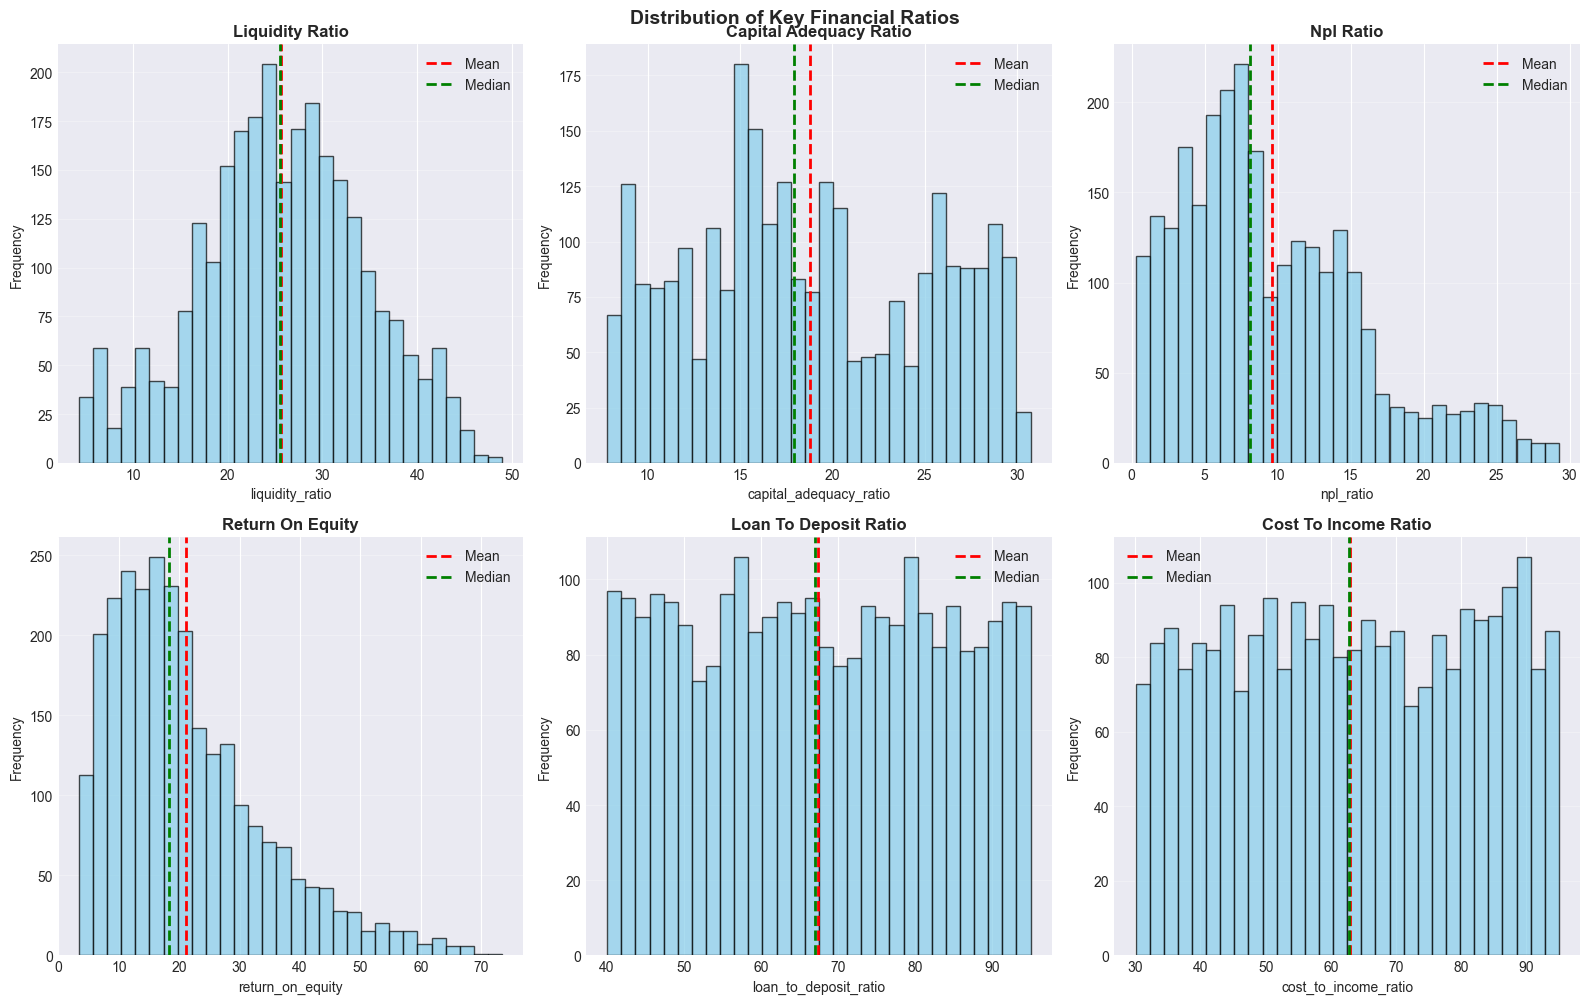

In [90]:
#Distribution plots for key financial ratios 
key_ratios = ['liquidity_ratio', 'capital_adequacy_ratio', 'npl_ratio', 
              'return_on_equity', 'loan_to_deposit_ratio', 'cost_to_income_ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()


for idx, col in enumerate(key_ratios):
    if col in df.columns:
        axes[idx].hist(df[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
        axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label='Median')
        axes[idx].set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)
        

plt.tight_layout()
plt.suptitle('Distribution of Key Financial Ratios', fontsize=14, fontweight='bold', y=1.00)
plt.show()

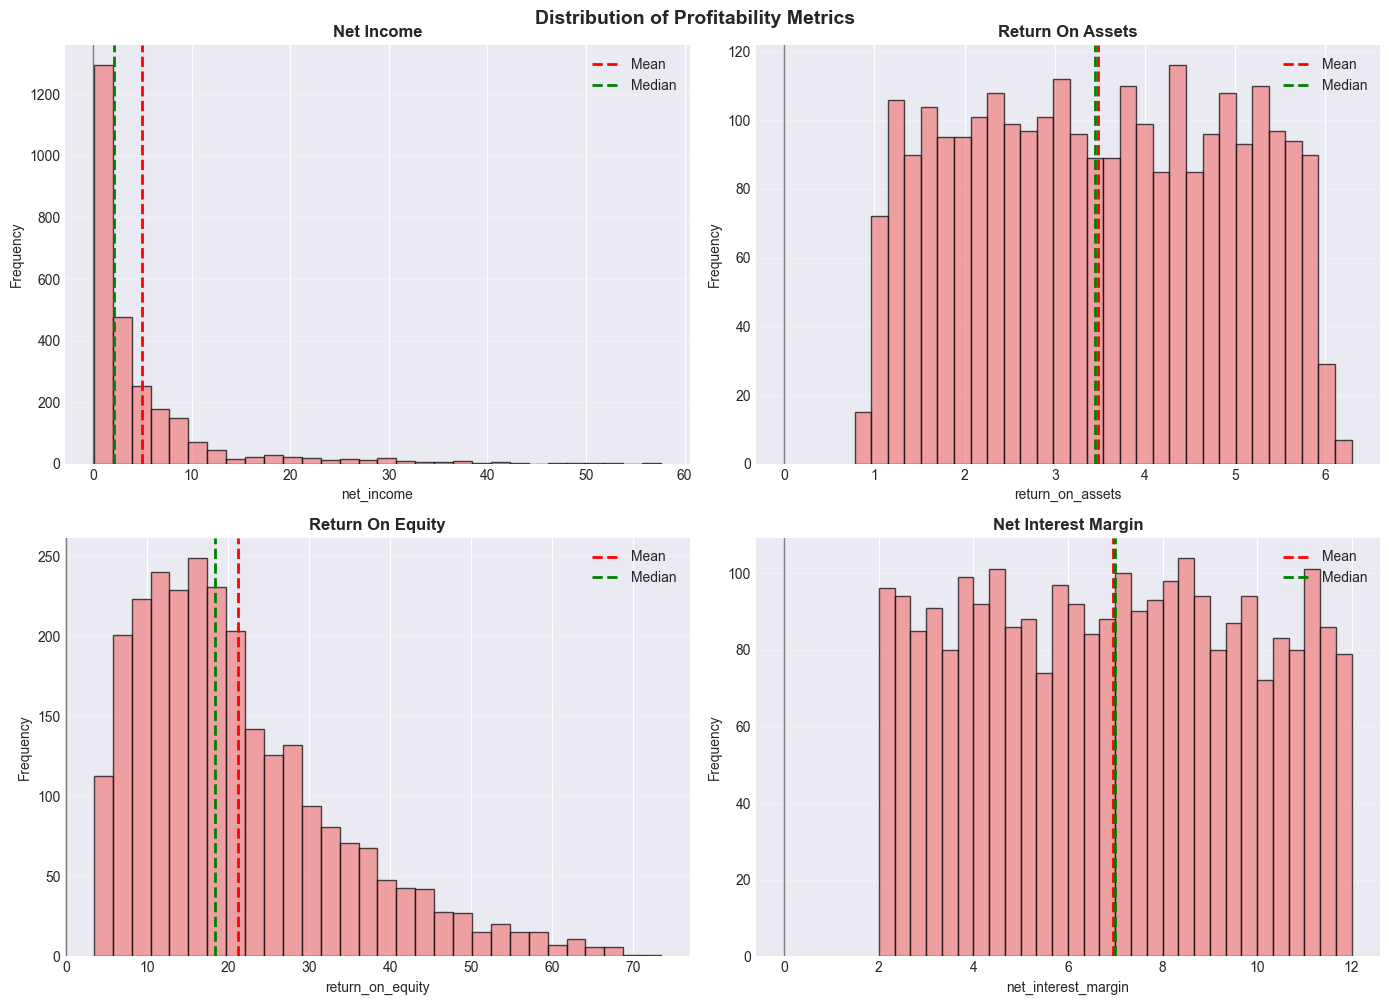

In [91]:
# Distribution plots for profitability metrics
profitability_cols = ['net_income', 'return_on_assets', 'return_on_equity', 'net_interest_margin']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(profitability_cols):
    if col in df.columns:
        axes[idx].hist(df[col].dropna(), bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
        axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label='Median')
        axes[idx].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        axes[idx].set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of Profitability Metrics', fontsize=14, fontweight='bold', y=1.00)
plt.show()

In [92]:
# Summary statistics for key ratios
print("\nKey Financial Ratios - Summary Statistics:")
print("-" * 90)
summary_stats = df[key_ratios].describe().T
summary_stats['skewness'] = df[key_ratios].skew()
summary_stats['kurtosis'] = df[key_ratios].kurtosis()
print(summary_stats.round(2))


Key Financial Ratios - Summary Statistics:
------------------------------------------------------------------------------------------
                         count   mean    std    min    25%    50%    75%  \
liquidity_ratio         2688.0  25.65   8.91   4.29  19.96  25.55  31.67   
capital_adequacy_ratio  2688.0  18.77   6.39   7.81  13.83  17.90  24.96   
npl_ratio               2688.0   9.63   6.32   0.27   4.94   8.14  13.60   
return_on_equity        2688.0  21.22  12.67   3.40  11.78  18.38  27.78   
loan_to_deposit_ratio   2688.0  67.34  15.97  40.02  53.89  66.99  80.96   
cost_to_income_ratio    2554.0  63.00  18.82  30.03  46.77  62.74  79.99   

                          max  skewness  kurtosis  
liquidity_ratio         48.96     -0.10     -0.30  
capital_adequacy_ratio  30.73      0.14     -1.13  
npl_ratio               29.26      0.84      0.22  
return_on_equity        73.48      1.13      1.10  
loan_to_deposit_ratio   94.99      0.01     -1.20  
cost_to_income_ratio

# Bivariate Analysis - Feature vs Target 

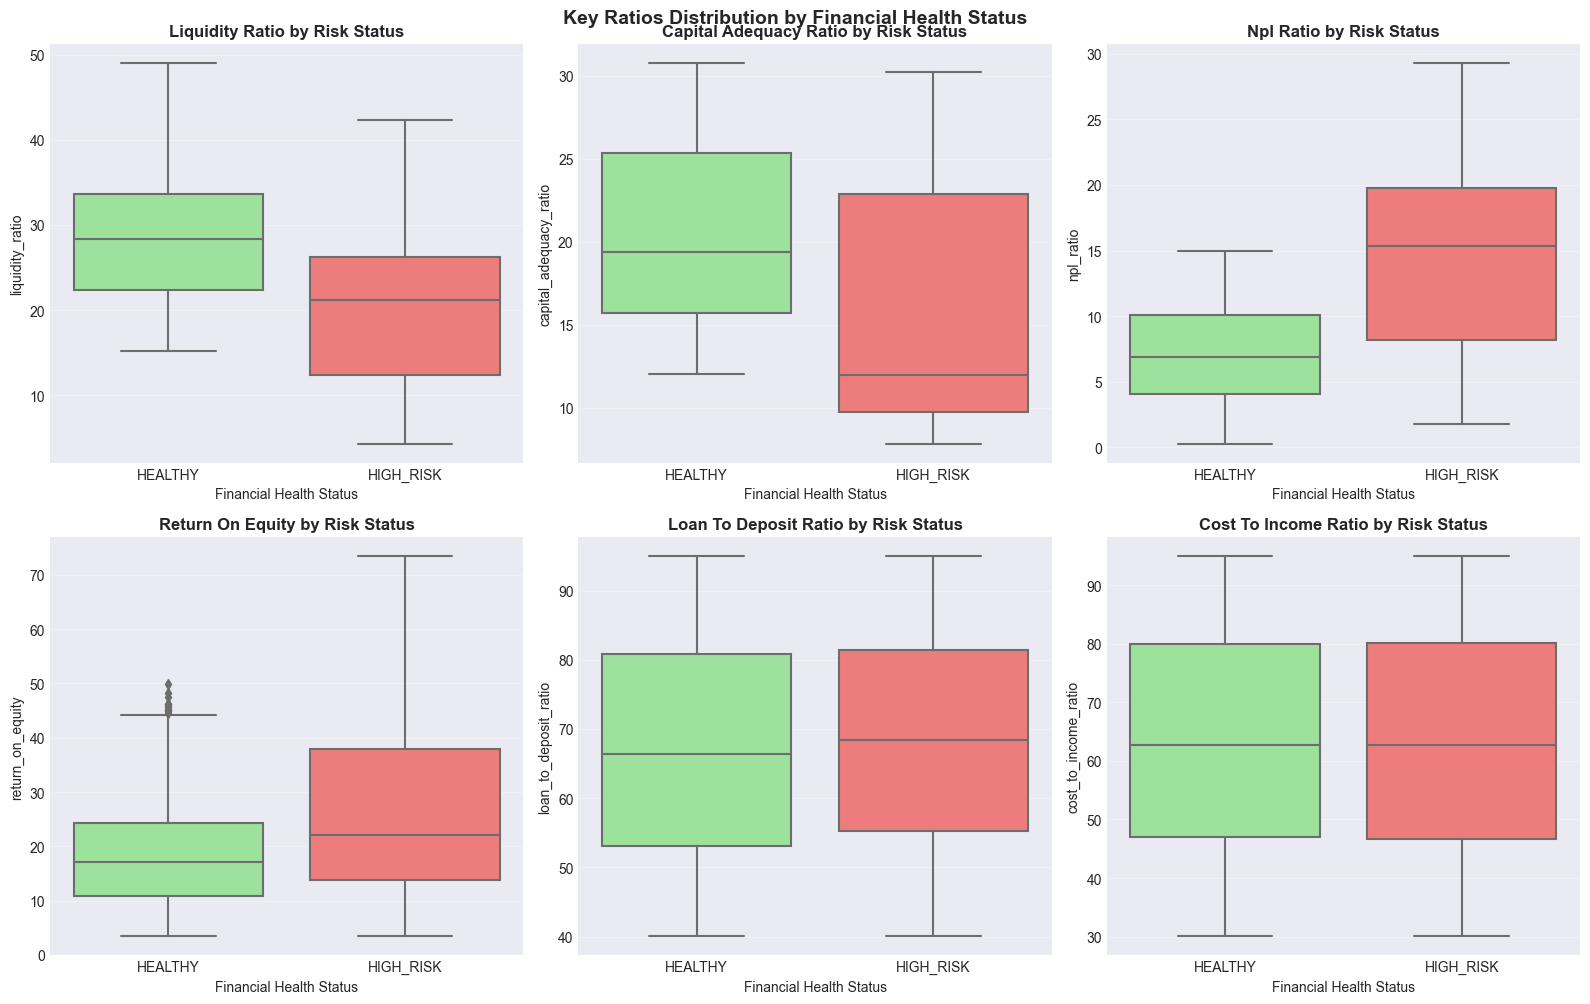

In [93]:
# Box plots for key ratios by financial health status
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_ratios):
    if col in df.columns:
        sns.boxplot(data=df, x='financial_health_status', y=col, ax=axes[idx], 
                   palette=['#90EE90', '#FF6B6B'])
        axes[idx].set_title(f'{col.replace("_", " ").title()} by Risk Status', fontweight='bold')
        axes[idx].set_xlabel('Financial Health Status')
        axes[idx].set_xticklabels(['HEALTHY', 'HIGH_RISK'])
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Key Ratios Distribution by Financial Health Status', fontsize=14, fontweight='bold', y=1.00)
plt.show()

In [94]:
# Statistical comparison between healthy and high-risk banks
print("\nMean Comparison: Healthy vs High-Risk Banks")
print("-" * 90)

comparison_metrics = key_ratios + profitability_cols
comparison_df = pd.DataFrame({
    'Feature': comparison_metrics,
    'Healthy_Mean': [df[df['financial_health_status']==0][col].mean() for col in comparison_metrics],
    'HighRisk_Mean': [df[df['financial_health_status']==1][col].mean() for col in comparison_metrics],
})

comparison_df['Difference'] = comparison_df['Healthy_Mean'] - comparison_df['HighRisk_Mean']
comparison_df['Pct_Difference'] = (comparison_df['Difference'] / comparison_df['Healthy_Mean'].abs()) * 100

print(comparison_df.round(2).to_string(index=False))


Mean Comparison: Healthy vs High-Risk Banks
------------------------------------------------------------------------------------------
               Feature  Healthy_Mean  HighRisk_Mean  Difference  Pct_Difference
       liquidity_ratio         28.51          20.16        8.35           29.27
capital_adequacy_ratio         20.25          15.93        4.32           21.34
             npl_ratio          7.10          14.48       -7.38         -103.92
      return_on_equity         18.45          26.53       -8.08          -43.77
 loan_to_deposit_ratio         66.88          68.20       -1.32           -1.97
  cost_to_income_ratio         62.98          63.03       -0.05           -0.07
            net_income          4.78           5.21       -0.43           -8.98
      return_on_assets          3.49           3.45        0.03            0.97
      return_on_equity         18.45          26.53       -8.08          -43.77
   net_interest_margin          6.92           6.99       -0.08 

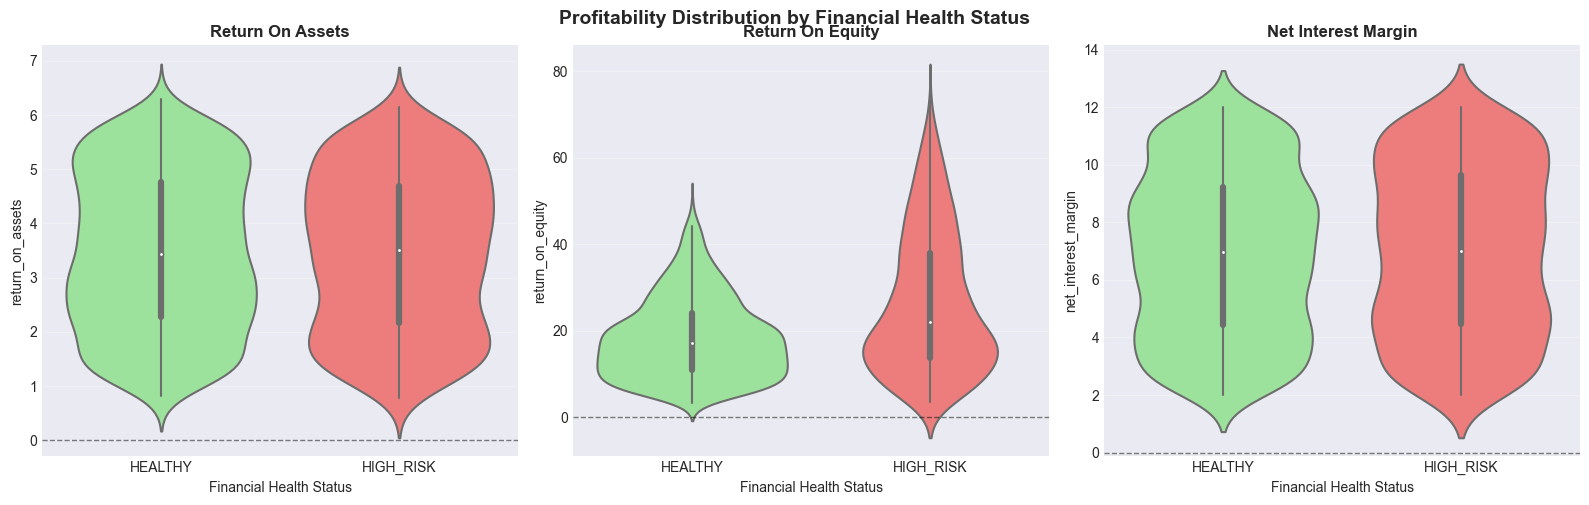

In [95]:
# Violin plots for profitability metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

profit_metrics = ['return_on_assets', 'return_on_equity', 'net_interest_margin']

for idx, col in enumerate(profit_metrics):
    if col in df.columns:
        sns.violinplot(data=df, x='financial_health_status', y=col, ax=axes[idx],
                      palette=['#90EE90', '#FF6B6B'])
        axes[idx].set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
        axes[idx].set_xlabel('Financial Health Status')
        axes[idx].set_xticklabels(['HEALTHY', 'HIGH_RISK'])
        axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Profitability Distribution by Financial Health Status', fontsize=14, fontweight='bold', y=1.00)
plt.show()

# Correlation Analysis 

In [96]:
# Compute correlation matrix for numerical features
correlation_features = [col for col in numerical_cols if df[col].dtype in ['float64', 'int64']]
corr_matrix = df[correlation_features].corr()

print(f"\nCorrelation Matrix Shape: {corr_matrix.shape}")
print(f"Analyzing {len(correlation_features)} numerical features")


Correlation Matrix Shape: (24, 24)
Analyzing 24 numerical features


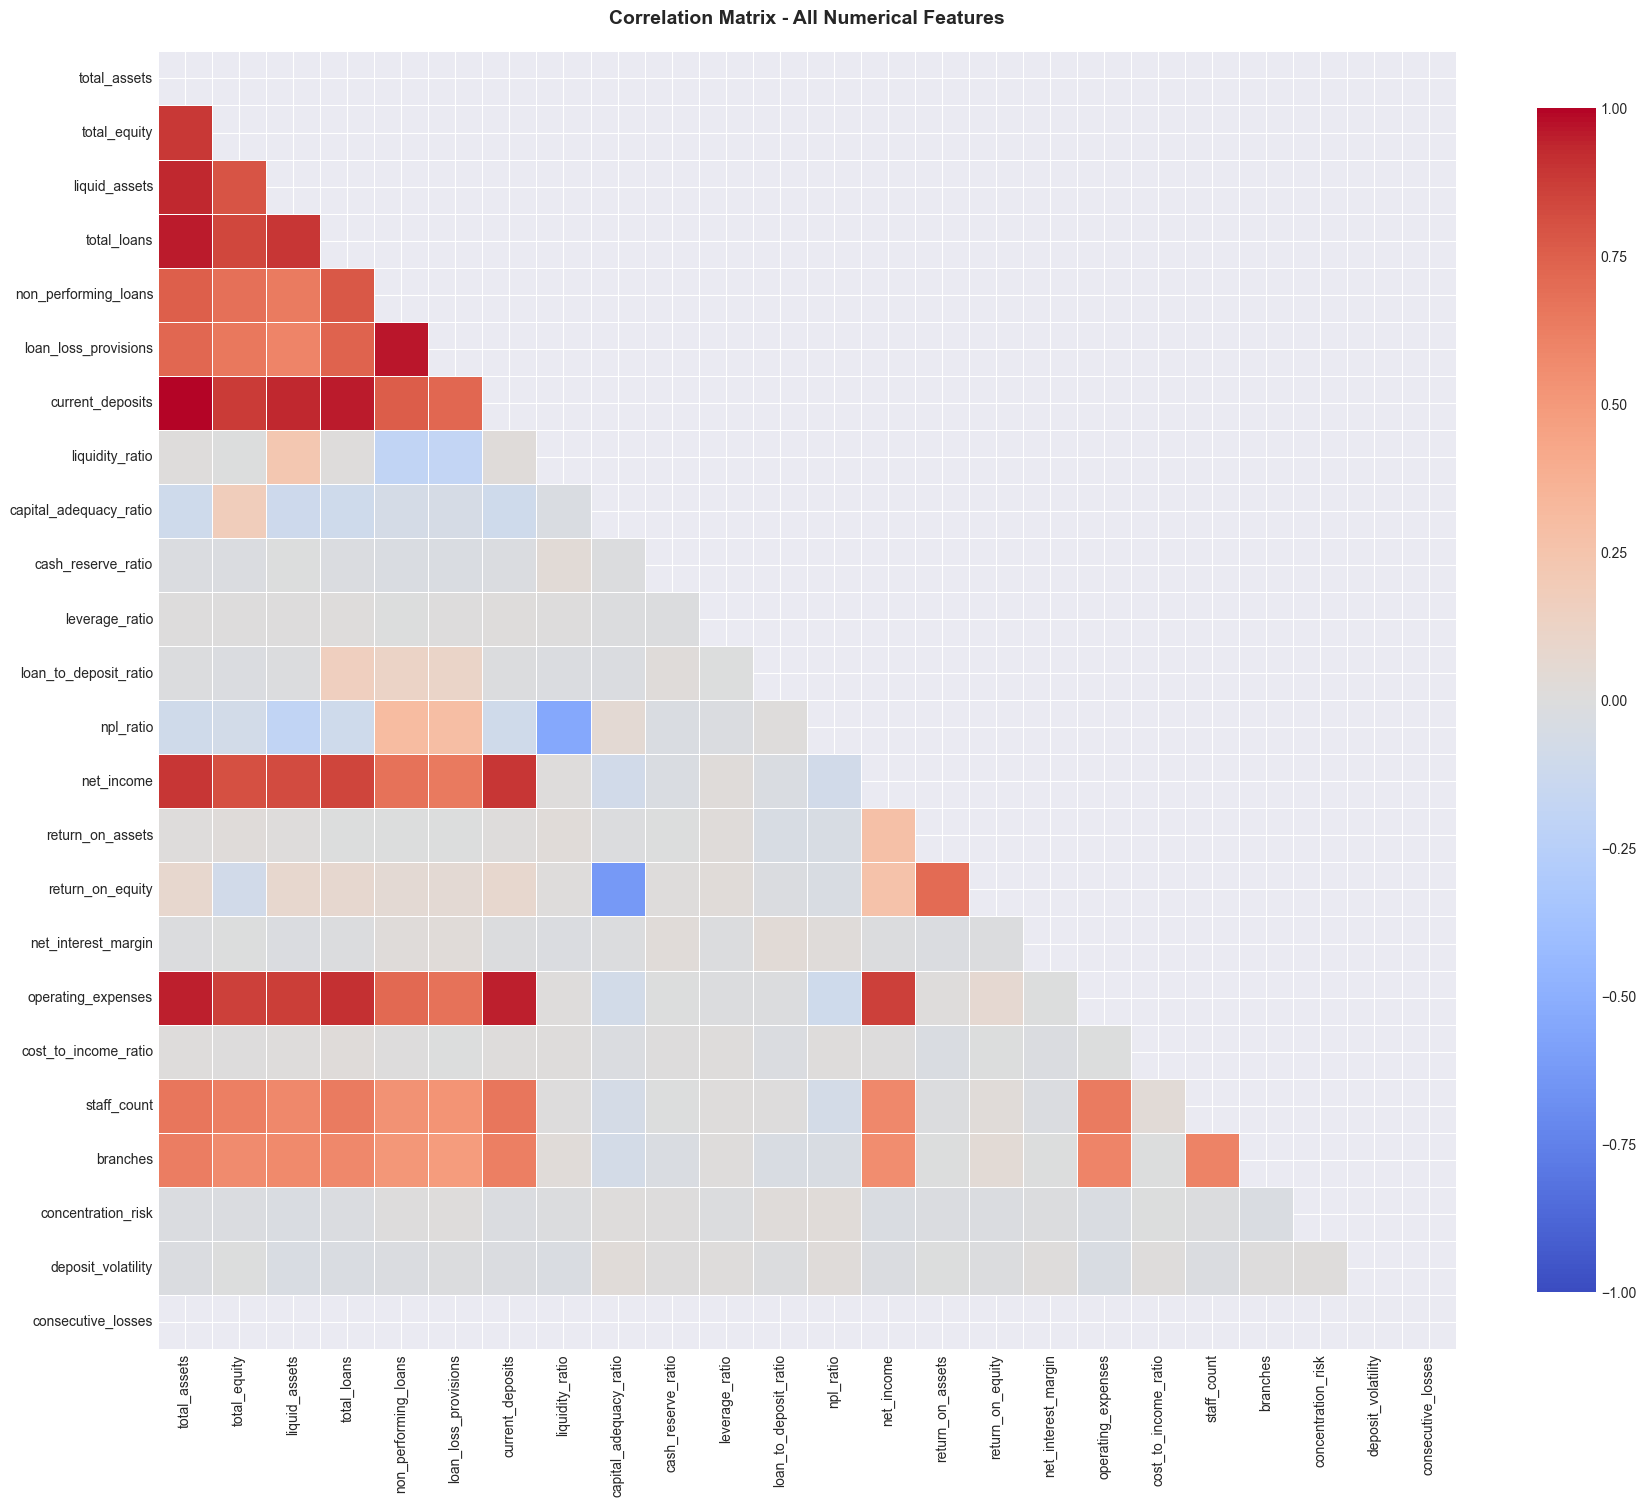

In [97]:
fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - All Numerical Features', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [98]:
# Identify highly correlated pairs (potential multicollinearity)
print("\nHighly Correlated Feature Pairs (|r| > 0.80):")
print("-" * 90)

# Get upper triangle of correlation matrix
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find highly correlated pairs
high_corr = [(col, row, upper_triangle.loc[row, col]) 
             for col in upper_triangle.columns 
             for row in upper_triangle.index 
             if abs(upper_triangle.loc[row, col]) > 0.80]

# Sort by absolute correlation
high_corr_sorted = sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)

if high_corr_sorted:
    for feat1, feat2, corr_val in high_corr_sorted[:15]:  # Top 15
        print(f"{feat1:30} <-> {feat2:30} : {corr_val:6.3f}")
else:
    print("No feature pairs with |r| > 0.80 found")


Highly Correlated Feature Pairs (|r| > 0.80):
------------------------------------------------------------------------------------------
current_deposits               <-> total_assets                   :  0.998
loan_loss_provisions           <-> non_performing_loans           :  0.967
current_deposits               <-> total_loans                    :  0.960
total_loans                    <-> total_assets                   :  0.957
operating_expenses             <-> total_assets                   :  0.950
operating_expenses             <-> current_deposits               :  0.946
liquid_assets                  <-> total_assets                   :  0.932
current_deposits               <-> liquid_assets                  :  0.931
operating_expenses             <-> total_loans                    :  0.907
net_income                     <-> total_assets                   :  0.896
total_loans                    <-> liquid_assets                  :  0.895
net_income                     <-> cu

In [99]:
# Correlation with target variable
target_correlations = df[correlation_features + ['financial_health_status']].corr()['financial_health_status'].drop('financial_health_status')
target_correlations = target_correlations.sort_values(ascending=False)

print("\nTop 15 Features Most Positively Correlated with HIGH_RISK:")
print("-" * 70)
print(target_correlations.head(15).to_string())

print("\n\nTop 15 Features Most Negatively Correlated with HIGH_RISK:")
print("-" * 70)
print(target_correlations.tail(15).to_string())


Top 15 Features Most Positively Correlated with HIGH_RISK:
----------------------------------------------------------------------
npl_ratio                5.54e-01
return_on_equity         3.03e-01
non_performing_loans     1.98e-01
loan_loss_provisions     1.85e-01
current_deposits         4.08e-02
loan_to_deposit_ratio    3.92e-02
total_loans              3.84e-02
total_assets             3.77e-02
net_income               2.72e-02
operating_expenses       1.58e-02
net_interest_margin      1.29e-02
branches                 1.16e-02
cash_reserve_ratio       4.61e-03
concentration_risk       2.67e-03
cost_to_income_ratio     1.17e-03


Top 15 Features Most Negatively Correlated with HIGH_RISK:
----------------------------------------------------------------------
operating_expenses        1.58e-02
net_interest_margin       1.29e-02
branches                  1.16e-02
cash_reserve_ratio        4.61e-03
concentration_risk        2.67e-03
cost_to_income_ratio      1.17e-03
deposit_volatilit

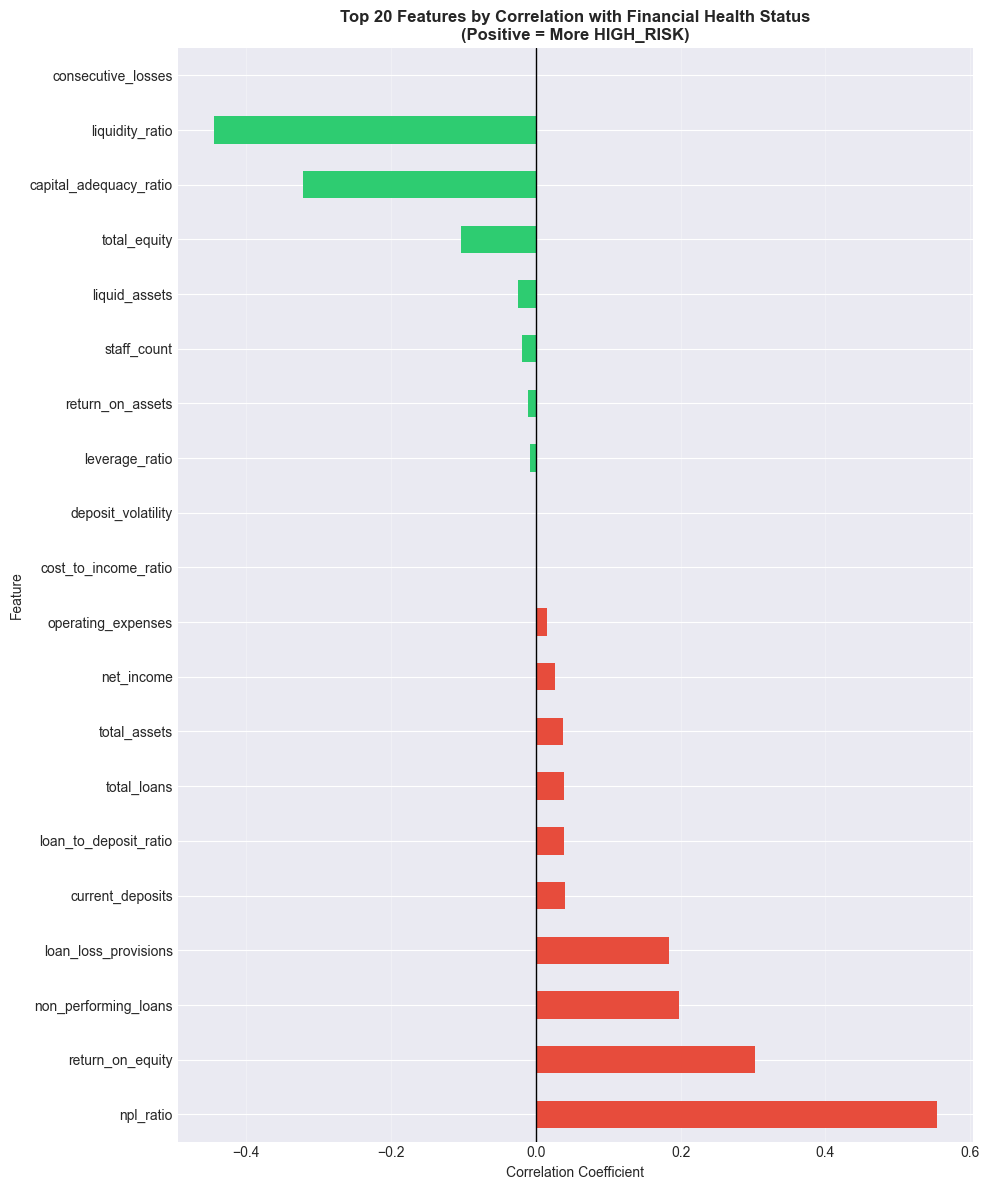

In [100]:
# Visualize correlations with target
fig, ax = plt.subplots(figsize=(10, 12))

# Select top and bottom features
top_features = pd.concat([target_correlations.head(10), target_correlations.tail(10)])
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_features.values]

top_features.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 20 Features by Correlation with Financial Health Status\n(Positive = More HIGH_RISK)', 
             fontweight='bold', fontsize=12)
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Feature')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Temporal Analysis - Quarterly Trends 

In [101]:
# Aggregate metrics by quarter
quarterly_agg = df.groupby('quarter_num')[key_ratios].mean()

print("\nQuarterly Average Trends:")
print("-" * 90)
print(quarterly_agg.round(2))


Quarterly Average Trends:
------------------------------------------------------------------------------------------
             liquidity_ratio  capital_adequacy_ratio  npl_ratio  \
quarter_num                                                       
1                      25.97                   18.79       9.12   
2                      25.88                   18.79       9.23   
3                      25.49                   18.81       9.48   
4                      25.63                   18.81       9.51   
5                      25.64                   18.80       9.54   
6                      25.96                   18.77       9.42   
7                      25.99                   18.75       9.47   
8                      25.33                   18.74       9.91   
9                      25.32                   18.73       9.96   
10                     25.48                   18.73       9.94   
11                     25.55                   18.72       9.98   
12         

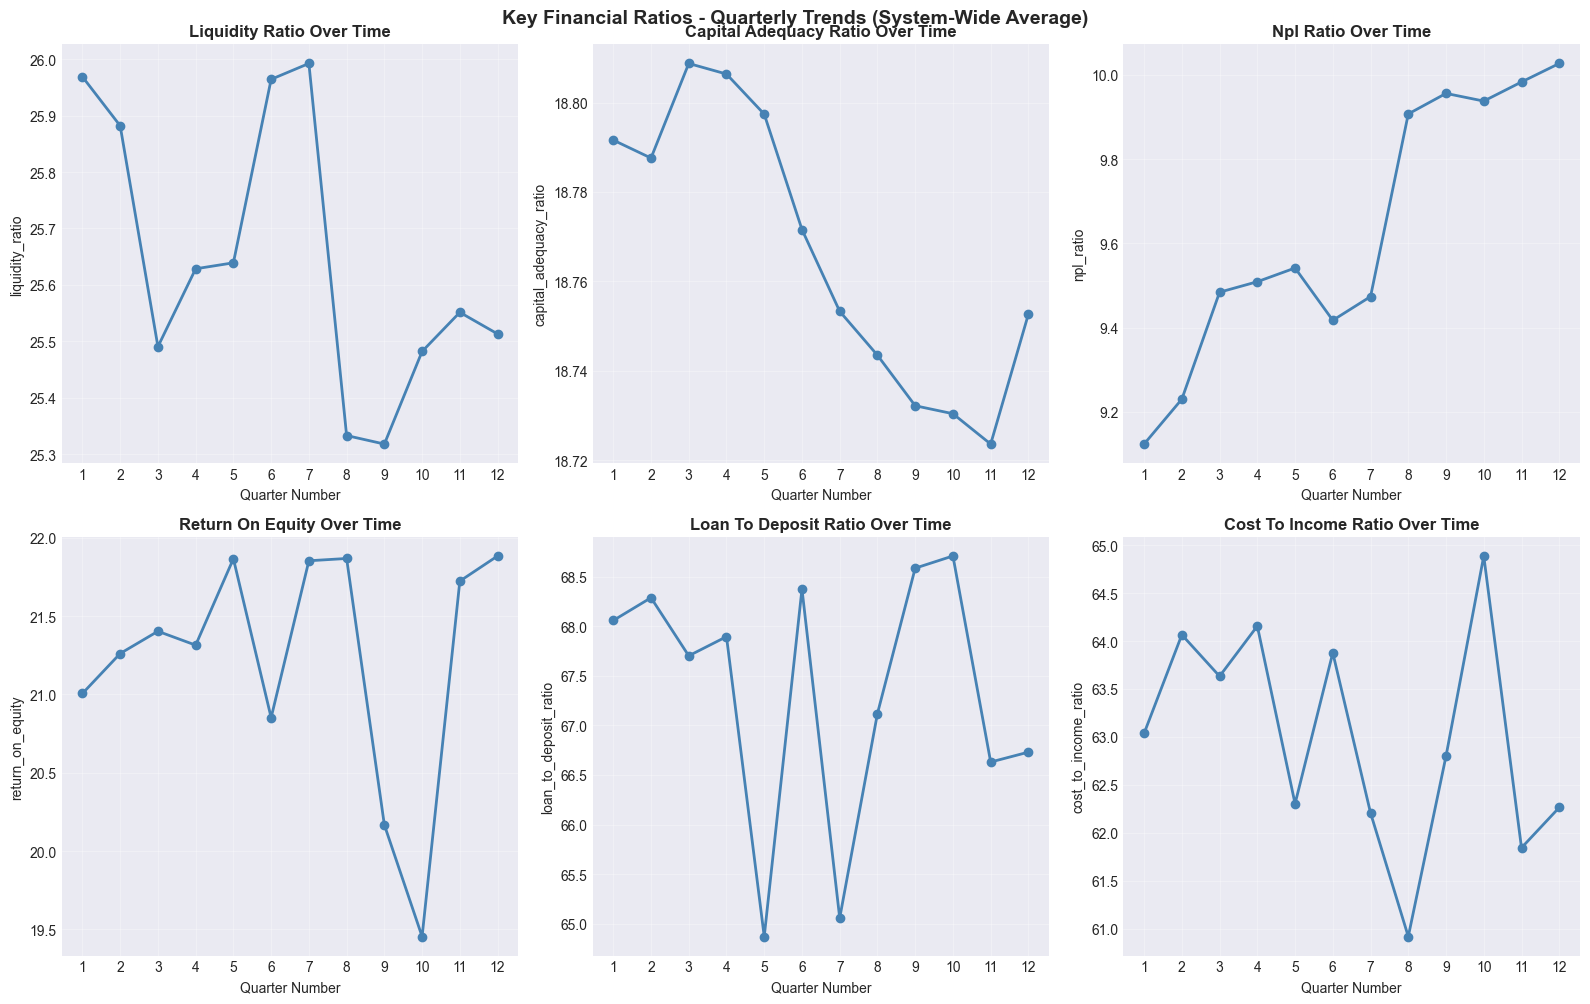

In [102]:
# Line plots for key ratios over time
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_ratios):
    if col in quarterly_agg.columns:
        axes[idx].plot(quarterly_agg.index, quarterly_agg[col], marker='o', 
                      linewidth=2, markersize=6, color='steelblue')
        axes[idx].set_title(f'{col.replace("_", " ").title()} Over Time', fontweight='bold')
        axes[idx].set_xlabel('Quarter Number')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xticks(range(1, 13))

plt.tight_layout()
plt.suptitle('Key Financial Ratios - Quarterly Trends (System-Wide Average)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.show()


High-Risk Percentage by Quarter:
----------------------------------------------------------------------
             high_risk_pct
quarter_num               
1                    30.80
2                    30.80
3                    33.04
4                    32.59
5                    33.93
6                    34.38
7                    34.38
8                    36.16
9                    36.16
10                   36.61
11                   36.16
12                   36.16


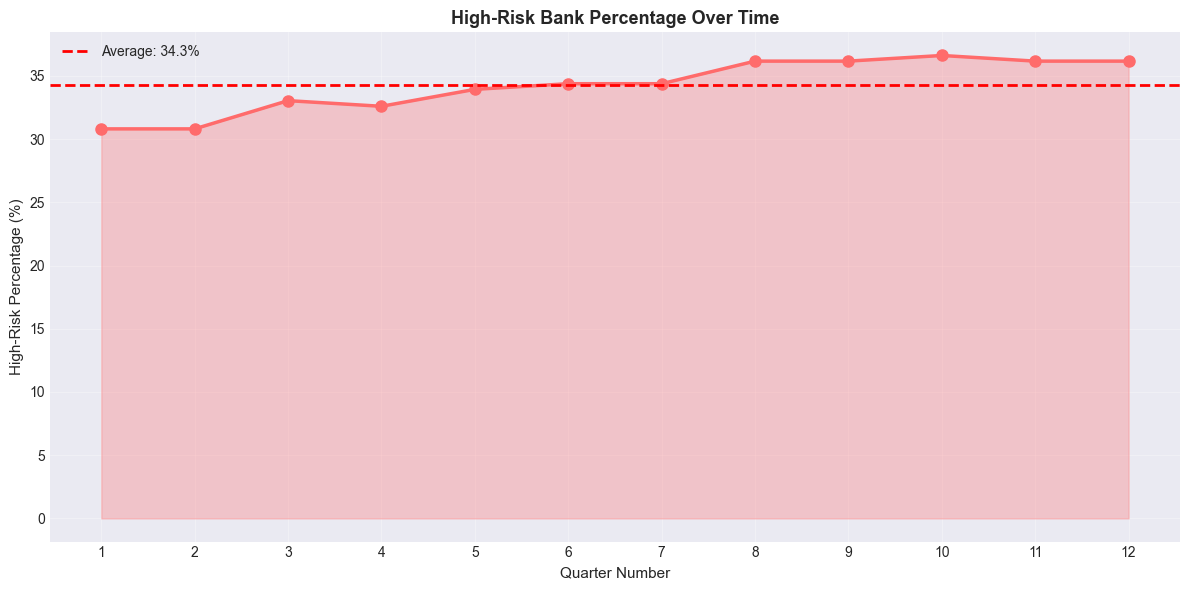

In [103]:
# Risk proportion over time
risk_over_time = df.groupby('quarter_num')['financial_health_status'].agg(['mean', 'count'])
risk_over_time['high_risk_pct'] = risk_over_time['mean'] * 100

print("\nHigh-Risk Percentage by Quarter:")
print("-" * 70)
print(risk_over_time[['high_risk_pct']].round(2))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(risk_over_time.index, risk_over_time['high_risk_pct'], 
        marker='o', linewidth=2.5, markersize=8, color='#FF6B6B')
ax.fill_between(risk_over_time.index, risk_over_time['high_risk_pct'], 
                alpha=0.3, color='#FF6B6B')
ax.set_title('High-Risk Bank Percentage Over Time', fontweight='bold', fontsize=13)
ax.set_xlabel('Quarter Number', fontsize=11)
ax.set_ylabel('High-Risk Percentage (%)', fontsize=11)
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)
ax.axhline(y=risk_over_time['high_risk_pct'].mean(), color='red', 
          linestyle='--', linewidth=2, label=f'Average: {risk_over_time["high_risk_pct"].mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

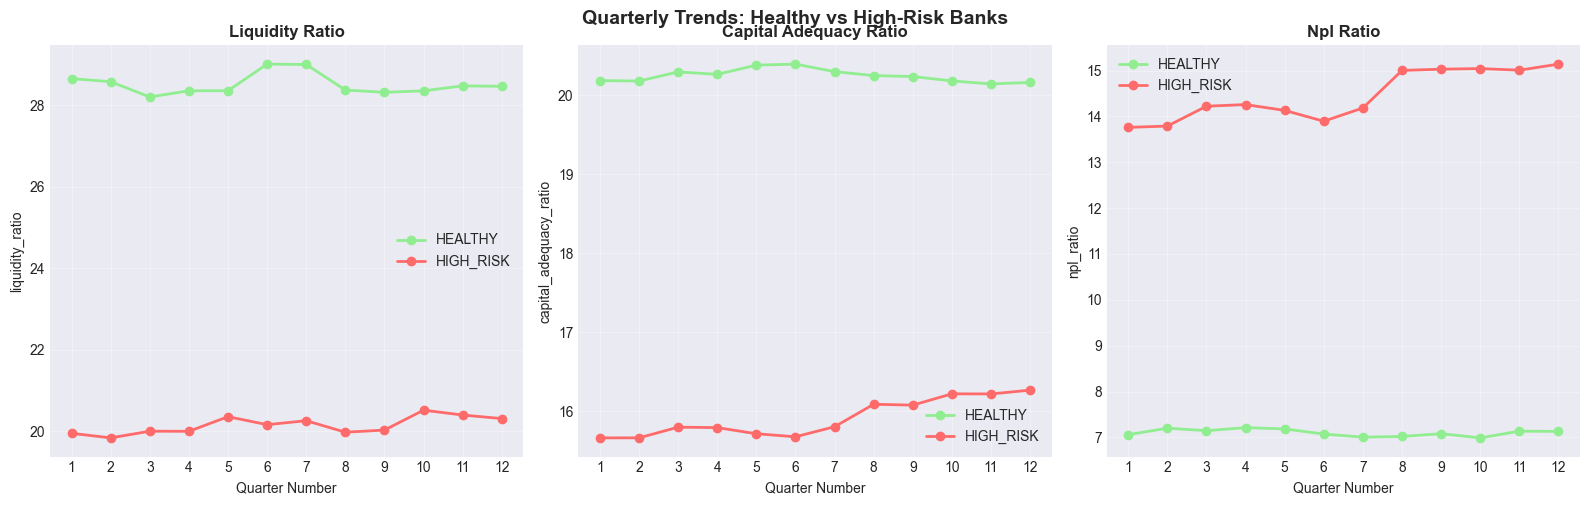

In [104]:
# Trend comparison: Healthy vs High-Risk banks
quarterly_by_status = df.groupby(['quarter_num', 'financial_health_status'])[['liquidity_ratio', 'capital_adequacy_ratio', 'npl_ratio']].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['liquidity_ratio', 'capital_adequacy_ratio', 'npl_ratio']

for idx, metric in enumerate(metrics):
    for status in [0, 1]:
        data = quarterly_by_status.xs(status, level=1)[metric]
        label = 'HEALTHY' if status == 0 else 'HIGH_RISK'
        color = '#90EE90' if status == 0 else '#FF6B6B'
        axes[idx].plot(data.index, data.values, marker='o', label=label, 
                      linewidth=2, markersize=6, color=color)
    
    axes[idx].set_title(f'{metric.replace("_", " ").title()}', fontweight='bold')
    axes[idx].set_xlabel('Quarter Number')
    axes[idx].set_ylabel(metric)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xticks(range(1, 13))

plt.tight_layout()
plt.suptitle('Quarterly Trends: Healthy vs High-Risk Banks', fontsize=14, fontweight='bold', y=1.00)
plt.show()

# Regional Analysis 

In [105]:
# Regional performance comparison
regional_metrics = df.groupby('region')[key_ratios + ['financial_health_status']].mean()
regional_metrics = regional_metrics.sort_values('financial_health_status', ascending=False)

print("\nRegional Performance Metrics (Sorted by Risk Level):")
print("-" * 90)
print(regional_metrics.round(2))


Regional Performance Metrics (Sorted by Risk Level):
------------------------------------------------------------------------------------------
               liquidity_ratio  capital_adequacy_ratio  npl_ratio  \
region                                                              
Upper West               20.74                   20.56      10.22   
Greater Accra            25.81                   18.23      10.32   
Bono                     25.60                   18.99      11.81   
Volta                    26.65                   19.22       8.84   
Central                  23.49                   19.04       9.54   
Northern                 25.34                   19.23      11.14   
Ashanti                  27.18                   18.52       8.00   
Western                  24.97                   16.79       8.27   
Upper East               27.49                   20.66       9.48   
Eastern                  25.99                   18.89      10.18   

               return_on_e

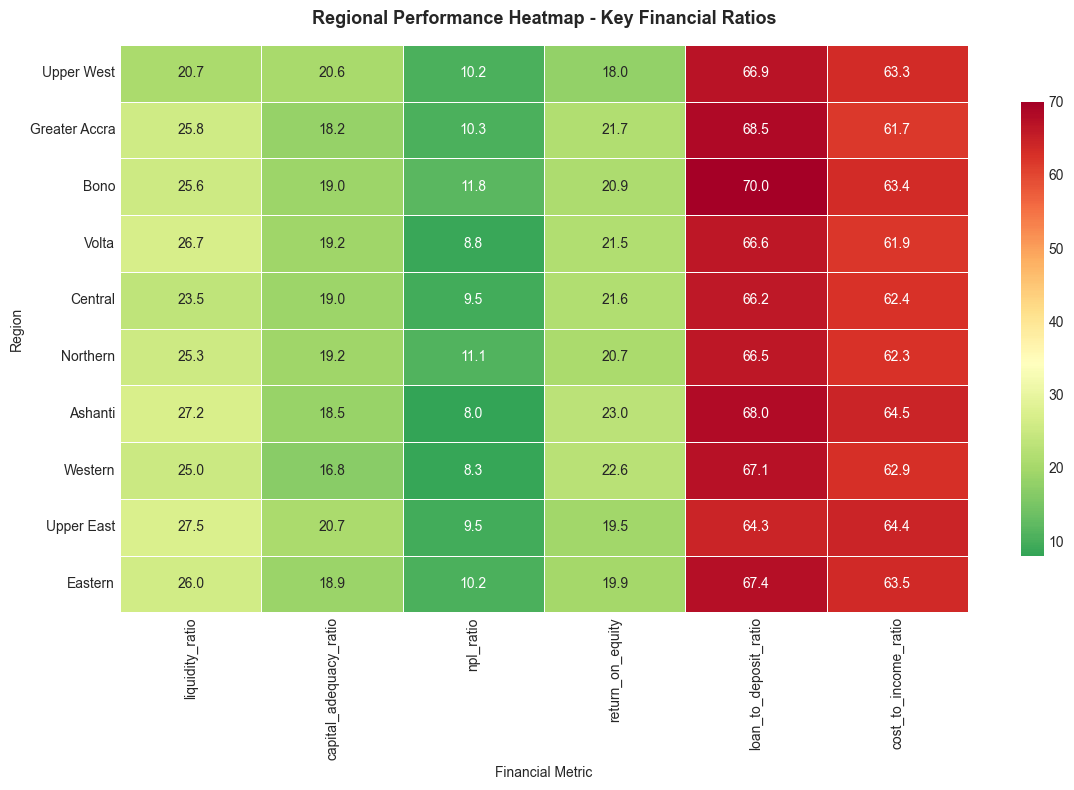

In [106]:
# Heatmap of regional performance
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regional_metrics[key_ratios], annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=regional_metrics[key_ratios].mean().mean(), ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Regional Performance Heatmap - Key Financial Ratios', 
            fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('Financial Metric')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

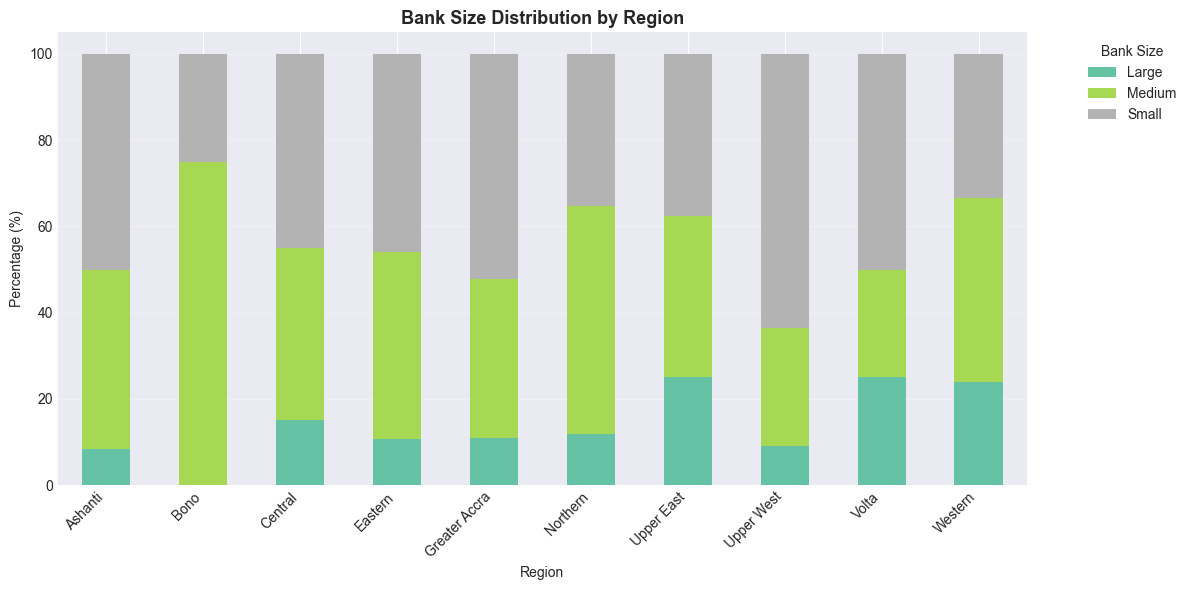

In [107]:
# Regional comparison - bank size distribution
regional_size_dist = pd.crosstab(df['region'], df['bank_size'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
regional_size_dist.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Bank Size Distribution by Region', fontweight='bold', fontsize=13)
ax.set_xlabel('Region')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Bank Size', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Missing Values Analysis 


Missing Values Summary:
----------------------------------------------------------------------
                      Missing_Count  Missing_Percentage
risk_reasons                   1767               65.74
concentration_risk              134                4.99
operating_expenses              134                4.99
staff_count                     134                4.99
branches                        134                4.99
cost_to_income_ratio            134                4.99
deposit_volatility              134                4.99


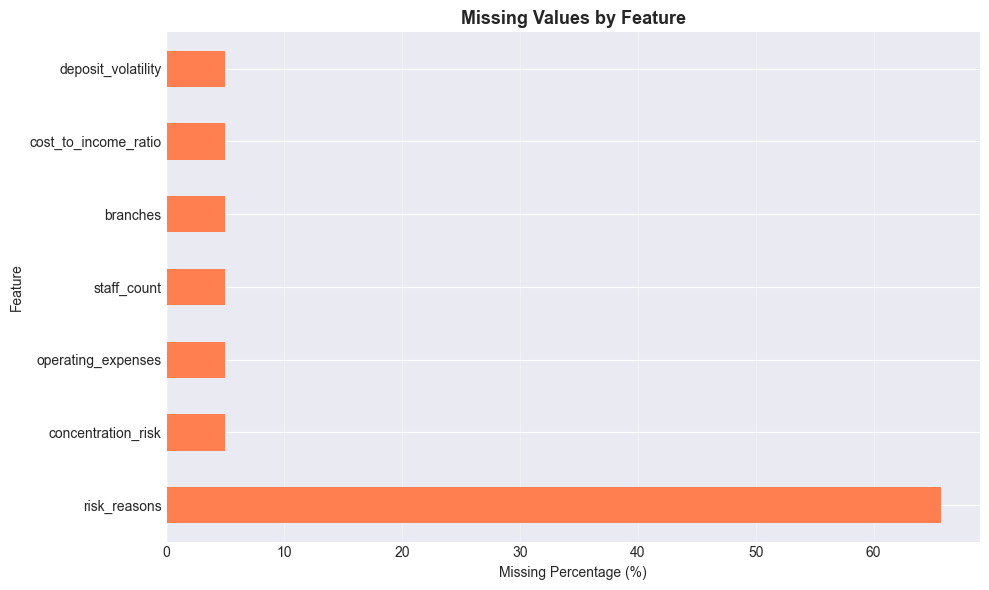

In [108]:
# Calculate missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

# Filter only columns with missing values
missing_df_filtered = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df_filtered) > 0:
    print("\nMissing Values Summary:")
    print("-" * 70)
    print(missing_df_filtered.round(2))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df_filtered['Missing_Percentage'].plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Missing Values by Feature', fontweight='bold', fontsize=13)
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values detected in the dataset")